# QSVM Hardware Parameter-Analyse (Noise Model Simulator)

**Modell:** Quantum Kernel SVM  
**Backend:** AerSimulator + IBM Noise Model (ibm_kingston)  
**Datensätze:** Iris + Breast Cancer  

Systematische Analyse der QSVM-Konfigurationsparameter:
Feature Map, Reps, Entanglement, Shots, optimization_level und Trainingsgröße.
Ergebnisse in `ergebnisse_hardware_analyse.csv`.


## 1 - Imports und Setup

In [2]:
import time
import itertools
import warnings
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from qiskit.circuit.library import zz_feature_map, pauli_feature_map
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_algorithms.state_fidelities import ComputeUncompute
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit_aer.primitives import SamplerV2
from qiskit_ibm_runtime import QiskitRuntimeService

warnings.filterwarnings('ignore')

RESULTS_FILE = 'ergebnisse_hardware_analyse.csv'
RANDOM_STATE = 42
TEST_SIZE    = 0.3

print('Setup abgeschlossen.')
from utils import load_ibm_token


Setup abgeschlossen.


## 2 - Noise Model laden (ibm_kingston)

In [3]:
service = QiskitRuntimeService(
    channel='ibm_quantum_platform',
    token=load_ibm_token()
)

backend      = service.backend('ibm_kingston')
noise_model  = NoiseModel.from_backend(backend)
coupling_map = backend.coupling_map
basis_gates  = noise_model.basis_gates

print(f'Noise Model geladen: {backend.name}')
print(f'Basis Gates: {basis_gates}')

qiskit_runtime_service._discover_account:WARNING:2026-05-10 11:45:48,185: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-05-10 11:45:53,406: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().
qiskit_runtime_service.backends:WARNING:2026-05-10 11:45:53,408: Using instance: open-instance, plan: open


Noise Model geladen: ibm_kingston
Basis Gates: ['cz', 'delay', 'id', 'if_else', 'measure', 'measure_2', 'reset', 'rz', 'sx', 'x']


## 3 - Hilfsfunktionen

In [4]:
def load_dataset(name, n_train=None):
    """
    Kanonische Datenpipeline:
    - Iris:         Features [0, 2], 3 Klassen, f1=weighted
    - BreastCancer: PCA(2), 2 Klassen, f1/precision/recall = binary
    """
    if name == 'Iris':
        data = load_iris()
        X    = data.data[:, [0, 2]]
        y    = data.target
        avg  = 'weighted'
    elif name == 'BreastCancer':
        data = load_breast_cancer()
        X    = data.data
        y    = data.target
        avg  = 'binary'
    else:
        raise ValueError(f'Unbekannter Datensatz: {name}')

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
    )

    if name == 'BreastCancer':
        pca     = PCA(n_components=2, random_state=RANDOM_STATE)
        X_train = pca.fit_transform(X_train)
        X_test  = pca.transform(X_test)

    if n_train is not None and n_train < len(X_train):
        _, X_train, _, y_train = train_test_split(
            X_train, y_train,
            test_size=n_train,
            random_state=RANDOM_STATE,
            stratify=y_train
        )

    scaler     = MinMaxScaler(feature_range=(0, 2 * np.pi))
    X_train_sc = scaler.fit_transform(X_train)
    X_test_sc  = scaler.transform(X_test)

    return X_train_sc, X_test_sc, y_train, y_test, avg


def build_feature_map(name, reps, entanglement):
    """Erstellt zz_feature_map oder pauli_feature_map."""
    if name == 'ZZFeatureMap':
        return zz_feature_map(feature_dimension=2, reps=reps, entanglement=entanglement)
    elif name == 'PauliFeatureMap':
        return pauli_feature_map(
            feature_dimension=2, reps=reps,
            entanglement=entanglement, paulis=['Z', 'ZZ']
        )
    else:
        raise ValueError(f'Unbekannte Feature Map: {name}')


def build_sampler_and_pm(shots, optimization_level):
    """Erstellt SamplerV2 mit Noise Model und PassManager."""
    sim_noisy = AerSimulator(
        noise_model=noise_model,
        coupling_map=coupling_map,
        basis_gates=basis_gates,
    )
    sampler = SamplerV2.from_backend(sim_noisy)
    sampler.options.default_shots = shots
    pm = generate_preset_pass_manager(
        backend=sim_noisy,
        optimization_level=optimization_level
    )
    return sampler, pm


def get_circuit_metrics(feature_map, pm):
    """
    Transpiliert einen Beispielschaltkreis (Dummy-Datenpunkt) und gibt
    Transpilationszeit, Tiefe und Gate Count zurueck.
    """
    try:
        dummy  = np.zeros(feature_map.num_parameters)
        bound  = feature_map.assign_parameters(dummy)
        t0     = time.time()
        trans  = pm.run(bound)
        t_tr   = round(time.time() - t0, 4)
        depth  = trans.depth()
        gates  = sum(trans.count_ops().values())
        return t_tr, depth, gates
    except Exception:
        return None, None, None


def run_experiment(params, lauf_nr):
    """Fuehrt einen einzelnen Lauf durch und gibt ein Ergebnis-Dict zurueck."""
    X_train, X_test, y_train, y_test, avg = load_dataset(
        params['datensatz'], params['n_train']
    )
    n_actual       = len(y_train)
    n_kernel_evals = n_actual * (n_actual + 1) // 2

    sampler, pm = build_sampler_and_pm(
        params['shots'], params['optimization_level']
    )
    feature_map = build_feature_map(
        params['feature_map'], params['feature_map_reps'], params['entanglement']
    )

    t_transpile, circ_depth, gate_count = get_circuit_metrics(feature_map, pm)

    # transpiler direkt an ComputeUncompute uebergeben - korrekt fuer qiskit-algorithms 0.4.0
    fidelity = ComputeUncompute(sampler=sampler, transpiler=pm)
    kernel   = FidelityQuantumKernel(
        feature_map=feature_map,
        fidelity=fidelity,
        max_circuits_per_job=params.get('max_circuits_per_job', None)
    )

    # Kernel-Matrix (Quantum-Teil)
    t0       = time.time()
    K_train  = kernel.evaluate(X_train)
    t_kernel = round(time.time() - t0, 4)

    # SVM Fit (klassischer Teil) - precomputed nutzt fertige Kernel-Matrix
    t0    = time.time()
    svc   = SVC(kernel='precomputed')
    svc.fit(K_train, y_train)
    t_fit = round(time.time() - t0, 4)

    # Inferenz
    t0      = time.time()
    K_test  = kernel.evaluate(X_test, X_train)
    y_pred  = svc.predict(K_test)
    t_infer = round(time.time() - t0, 4)

    acc       = round(accuracy_score(y_test, y_pred), 4)
    f1        = round(f1_score(y_test, y_pred, average=avg), 4)
    precision = round(precision_score(y_test, y_pred, average=avg, zero_division=0), 4)
    recall    = round(recall_score(y_test, y_pred, average=avg, zero_division=0), 4)

    return {
        'timestamp':          datetime.datetime.now().isoformat(),
        'lauf':               lauf_nr,
        'datensatz':          params['datensatz'],
        'n_train_soll':       params['n_train'],
        'n_train_actual':     n_actual,
        'n_test':             len(y_test),
        'n_kernel_evals':     n_kernel_evals,
        'feature_map':        params['feature_map'],
        'feature_map_reps':   params['feature_map_reps'],
        'entanglement':       params['entanglement'],
        'shots':              params['shots'],
        'optimization_level': params['optimization_level'],
        'circ_depth':         circ_depth,
        'gate_count':         gate_count,
        'modell':             'Quantum Kernel SVM',
        'accuracy':           acc,
        'f1_score':           f1,
        'precision':          precision,
        'recall':             recall,
        't_transpile_s':      t_transpile,
        't_kernel_s':         t_kernel,
        't_fit_s':            t_fit,
        't_infer_s':          t_infer,
        't_gesamt_s':         round((t_transpile or 0) + t_kernel + t_fit + t_infer, 4),
        'status':             'OK'
    }


def save_result(results, result):
    results.append(result)
    pd.DataFrame(results).to_csv(RESULTS_FILE, index=False)


def run_grid(grid, results, offset=0):
    """Fuehrt alle Kombinationen eines Parameter-Grids aus."""
    keys         = list(grid.keys())
    combinations = list(itertools.product(*grid.values()))
    total        = len(combinations)
    print(f'{total} Konfigurationen. Starte...\n')

    for i, combo in enumerate(combinations):
        params = dict(zip(keys, combo))
        print(f'[{i+1}/{total}] {params}')
        try:
            result = run_experiment(params, lauf_nr=offset + i + 1)
            print(f'  Acc: {result["accuracy"]:.4f} | F1: {result["f1_score"]:.4f} | '
                  f't_kernel: {result["t_kernel_s"]}s | depth: {result["circ_depth"]}')
        except Exception as e:
            print(f'  FEHLER: {e}')
            result = {k: params.get(k, None) for k in keys}
            result.update({
                'lauf':      offset + i + 1,
                'modell':    'Quantum Kernel SVM',
                'timestamp': datetime.datetime.now().isoformat(),
                'status':    f'FEHLER: {str(e)}'
            })
        save_result(results, result)

    print(f'\nAbgeschlossen. Ergebnisse in {RESULTS_FILE}')


print('Hilfsfunktionen definiert.')

Hilfsfunktionen definiert.


## 4 - Parameter-Grids

In [5]:
# Hauptgrid - optimization_level fix auf 1 (Literaturempfehlung für NISQ-Hardware)
PARAM_GRID = {
    'datensatz':          ['Iris', 'BreastCancer'],
    'n_train':            [30, 60, 90],
    'feature_map':        ['ZZFeatureMap', 'PauliFeatureMap'],
    'feature_map_reps':   [1, 2],
    'entanglement':       ['linear', 'circular', 'full'],
    'shots':              [128, 256, 512, 1024],
    'optimization_level': [1],  # fix - Vergleich mit Level 3 in Abschnitt 13
}

# Schnelltest - Extremwerte für ersten Überblick
QUICK_GRID = {
    'datensatz':          ['Iris'],
    'n_train':            [30],
    'feature_map':        ['ZZFeatureMap', 'PauliFeatureMap'],
    'feature_map_reps':   [1, 2],
    'entanglement':       ['linear', 'full'],
    'shots':              [128, 1024],
    'optimization_level': [1],
}

total_full  = 1
total_quick = 1
for v in PARAM_GRID.values(): total_full  *= len(v)
for v in QUICK_GRID.values(): total_quick *= len(v)

print(f'Hauptgrid:        {total_full} Kombinationen (~{total_full * 90 // 60} Minuten)')
print(f'Schnelltest-Grid: {total_quick} Kombinationen (~{total_quick * 90 // 60} Minuten)')

Hauptgrid:        288 Kombinationen (~432 Minuten)
Schnelltest-Grid: 16 Kombinationen (~24 Minuten)


## 5 - Schnelltest ausführen

In [6]:
results = []
run_grid(QUICK_GRID, results, offset=0)

16 Konfigurationen. Starte...

[1/16] {'datensatz': 'Iris', 'n_train': 30, 'feature_map': 'ZZFeatureMap', 'feature_map_reps': 1, 'entanglement': 'linear', 'shots': 128, 'optimization_level': 1}
  Acc: 0.5778 | F1: 0.5700 | t_kernel: 29.1417s | depth: 13
[2/16] {'datensatz': 'Iris', 'n_train': 30, 'feature_map': 'ZZFeatureMap', 'feature_map_reps': 1, 'entanglement': 'linear', 'shots': 1024, 'optimization_level': 1}
  Acc: 0.5333 | F1: 0.5232 | t_kernel: 28.9844s | depth: 13
[3/16] {'datensatz': 'Iris', 'n_train': 30, 'feature_map': 'ZZFeatureMap', 'feature_map_reps': 1, 'entanglement': 'full', 'shots': 128, 'optimization_level': 1}
  Acc: 0.5556 | F1: 0.5470 | t_kernel: 28.5199s | depth: 13
[4/16] {'datensatz': 'Iris', 'n_train': 30, 'feature_map': 'ZZFeatureMap', 'feature_map_reps': 1, 'entanglement': 'full', 'shots': 1024, 'optimization_level': 1}
  Acc: 0.5333 | F1: 0.5203 | t_kernel: 28.0019s | depth: 13
[5/16] {'datensatz': 'Iris', 'n_train': 30, 'feature_map': 'ZZFeatureMap', 'fea

## 6 - Hauptlauf ausführen

96 Kombinationen

In [ ]:
run_grid(PARAM_GRID, results, offset=len(results))

288 Konfigurationen. Starte...

[1/288] {'datensatz': 'Iris', 'n_train': 30, 'feature_map': 'ZZFeatureMap', 'feature_map_reps': 1, 'entanglement': 'linear', 'shots': 128, 'optimization_level': 1}


## 7 - Auswertung laden

In [6]:
df    = pd.read_csv(RESULTS_FILE)
df_ok = df[df['status'] == 'OK'].copy()

print(f'Erfolgreiche Läufe: {len(df_ok)} / {len(df)}')
print(f'Fehlgeschlagen:     {len(df) - len(df_ok)}')

Erfolgreiche Läufe: 164 / 164
Fehlgeschlagen:     0


## 8 - Laufzeit-Analyse

In [7]:
for group_col in ['feature_map', 'entanglement', 'optimization_level', 'shots']:
    print(f'=== t_kernel_s nach {group_col} ===')
    print(df_ok.groupby(group_col)['t_kernel_s'].agg(['mean', 'min', 'max']).round(3))
    print()

=== t_kernel_s nach feature_map ===
                    mean     min      max
feature_map                              
PauliFeatureMap  123.391  28.056  288.129
ZZFeatureMap     116.867  21.088  279.630

=== t_kernel_s nach entanglement ===
                 mean     min      max
entanglement                          
circular      132.671  28.056  279.630
full          118.486  28.002  279.424
linear        111.411  21.088  288.129

=== t_kernel_s nach optimization_level ===
                       mean     min      max
optimization_level                          
1                   120.049  21.088  288.129

=== t_kernel_s nach shots ===
          mean     min      max
shots                          
128    111.400  21.088  277.119
256    129.777  28.056  276.979
512    129.986  21.397  288.129
1024   112.531  28.002  279.630



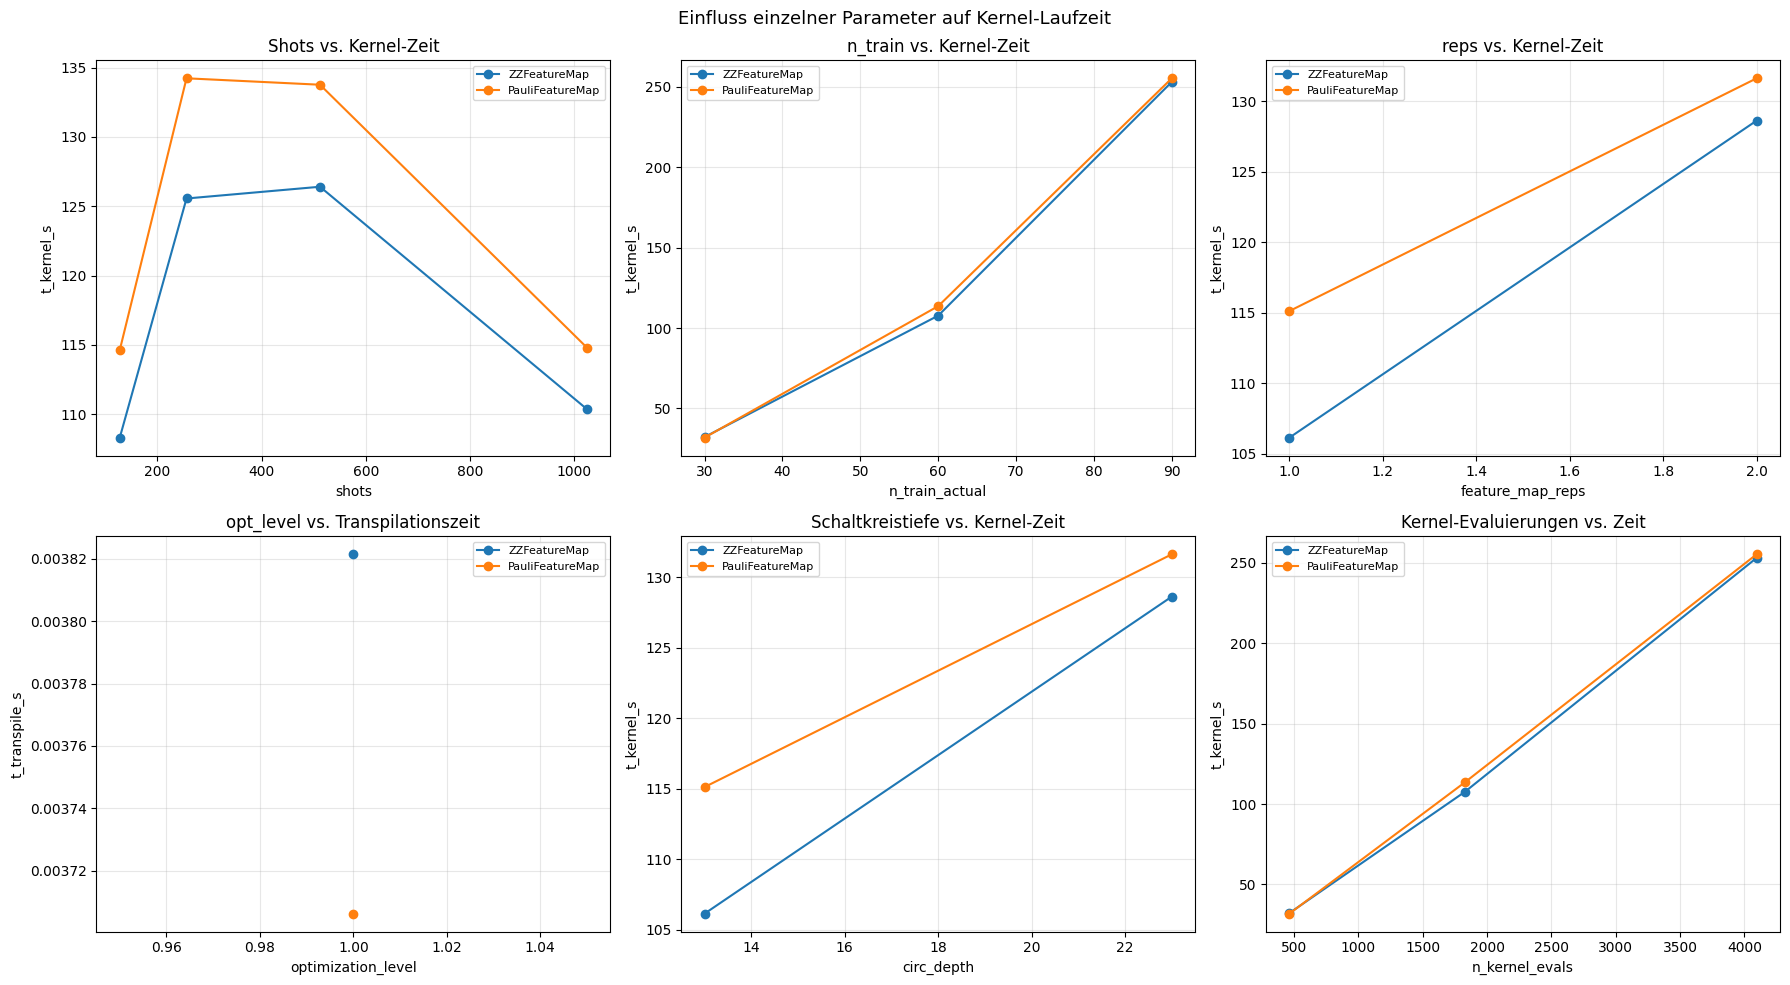

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Einfluss einzelner Parameter auf Kernel-Laufzeit', fontsize=13)

plot_params = [
    ('shots',              't_kernel_s',    'Shots vs. Kernel-Zeit'),
    ('n_train_actual',     't_kernel_s',    'n_train vs. Kernel-Zeit'),
    ('feature_map_reps',   't_kernel_s',    'reps vs. Kernel-Zeit'),
    ('optimization_level', 't_transpile_s', 'opt_level vs. Transpilationszeit'),
    ('circ_depth',         't_kernel_s',    'Schaltkreistiefe vs. Kernel-Zeit'),
    ('n_kernel_evals',     't_kernel_s',    'Kernel-Evaluierungen vs. Zeit'),
]

for ax, (x_col, y_col, title) in zip(axes.flat, plot_params):
    for fm in df_ok['feature_map'].unique():
        subset  = df_ok[df_ok['feature_map'] == fm]
        grouped = subset.groupby(x_col)[y_col].mean()
        ax.plot(grouped.index, grouped.values, marker='o', label=fm)
    ax.set_xlabel(x_col)
    ax.set_ylabel(y_col)
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('hardware_analyse_laufzeit.png', dpi=150, bbox_inches='tight')
plt.show()

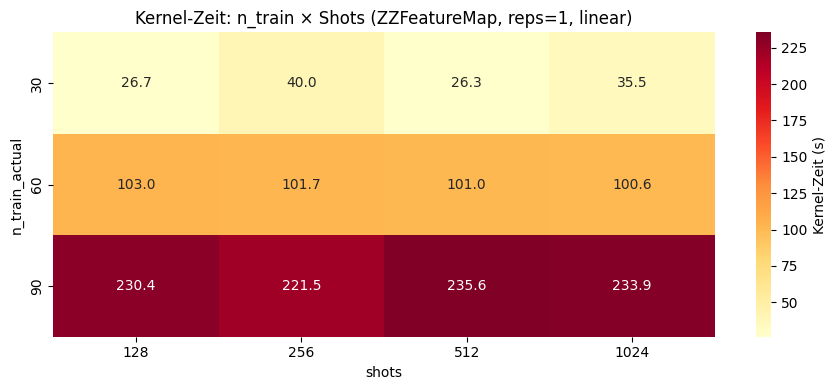

In [9]:
# Heatmap: n_train x shots -> Kernel-Zeit (ZZFeatureMap, reps=1, linear)
subset = df_ok[
    (df_ok['feature_map'] == 'ZZFeatureMap') &
    (df_ok['feature_map_reps'] == 1) &
    (df_ok['entanglement'] == 'linear')
]
if not subset.empty:
    pivot = subset.pivot_table(
        index='n_train_actual', columns='shots',
        values='t_kernel_s', aggfunc='mean'
    )
    fig, ax = plt.subplots(figsize=(9, 4))
    sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
                cbar_kws={'label': 'Kernel-Zeit (s)'}, ax=ax)
    ax.set_title('Kernel-Zeit: n_train × Shots (ZZFeatureMap, reps=1, linear)')
    plt.tight_layout()
    plt.savefig('hardware_analyse_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()

## 9 - Schaltkreis-Analyse

In [14]:
from qiskit_machine_learning.algorithms import VQC
import inspect
print(inspect.signature(VQC.__init__))

(self, num_qubits: 'int | None' = None, feature_map: 'QuantumCircuit | None' = None, ansatz: 'QuantumCircuit | None' = None, loss: 'str | Loss' = 'cross_entropy', optimizer: 'Optimizer | Minimizer | None' = None, warm_start: 'bool' = False, initial_point: 'np.ndarray | None' = None, callback: 'Callable[[np.ndarray, float], None] | None' = None, *, sampler: 'BaseSamplerV2 | None' = None, interpret: 'Callable[[int], int | tuple[int, ...]] | None' = None, output_shape: 'int | None' = None, pass_manager: 'BasePassManager | None' = None) -> 'None'


In [10]:
print('=== Schaltkreistiefe nach Feature Map, reps und entanglement ===')
print(df_ok.groupby(['feature_map', 'feature_map_reps', 'entanglement'])[
    ['circ_depth', 'gate_count']
].mean().round(1))

print('\n=== Korrelation: Schaltkreistiefe vs. Laufzeit ===')
print(df_ok[['circ_depth', 'gate_count', 't_kernel_s', 't_transpile_s']].corr().round(3))

=== Schaltkreistiefe nach Feature Map, reps und entanglement ===
                                               circ_depth  gate_count
feature_map     feature_map_reps entanglement                        
PauliFeatureMap 1                circular            13.0        13.0
                                 full                13.0        13.0
                                 linear              13.0        13.0
                2                circular            23.0        26.0
                                 full                23.0        26.0
                                 linear              23.0        26.0
ZZFeatureMap    1                circular            13.0        13.0
                                 full                13.0        13.0
                                 linear              13.0        13.0
                2                circular            23.0        26.0
                                 full                23.0        26.0
                         

## 10 - Vorhersagegüte

In [11]:
print('=== Güte nach Feature Map und entanglement ===')
print(df_ok.groupby(['feature_map', 'entanglement'])[
    ['accuracy', 'f1_score', 'precision', 'recall']
].mean().round(4))

print('\n=== Güte nach shots ===')
print(df_ok.groupby('shots')[['accuracy', 'f1_score']].mean().round(4))

=== Güte nach Feature Map und entanglement ===
                              accuracy  f1_score  precision  recall
feature_map     entanglement                                       
PauliFeatureMap circular        0.5259    0.5250     0.5376  0.5259
                full            0.5302    0.5295     0.5413  0.5302
                linear          0.5349    0.5341     0.5451  0.5349
ZZFeatureMap    circular        0.5352    0.5338     0.5449  0.5352
                full            0.5476    0.5464     0.5570  0.5476
                linear          0.5500    0.5659     0.5638  0.5824

=== Güte nach shots ===
       accuracy  f1_score
shots                    
128      0.5408    0.5415
256      0.5319    0.5359
512      0.5342    0.5377
1024     0.5431    0.5446


## 11 - Beste Konfiguration identifizieren

Kriterium: Minimale Kernel-Zeit bei Accuracy >= 0.70.

In [30]:
MIN_ACCURACY = 0.62
MAX_GESAMT_S = 480  # 5 Minuten - konservativer Puffer für Hardware

df_filtered = df_ok[
    (df_ok['accuracy'] >= MIN_ACCURACY) &
    (df_ok['t_gesamt_s'] <= MAX_GESAMT_S) #&
    #(df_ok['datensatz'] == 'Iris')  # BC explizit ausschließen wegen Inferenzzeit
].sort_values('t_kernel_s')

print(f'Konfigurationen mit Accuracy >= {MIN_ACCURACY} und t_gesamt <= {MAX_GESAMT_S}s: {len(df_filtered)}')
print(f'\nTop 10 schnellste:')
cols = [
    'datensatz', 'n_train_actual', 'feature_map', 'feature_map_reps',
    'entanglement', 'shots', 'optimization_level',
    'circ_depth', 'accuracy', 'f1_score', 't_kernel_s', 't_infer_s', 't_gesamt_s'
]
print(df_filtered[cols].head(10).to_string(index=False))

if len(df_filtered) > 0:
    beste = df_filtered.iloc[0]
    print(f'\n=== EMPFOHLENE KONFIGURATION FÜR HARDWARE-EXPERIMENT ===')
    for col in cols:
        print(f'  {col}: {beste[col]}')
    print(f'\n  Geschätzte Kernel-Evaluierungen (Training): {int(beste["n_train_actual"]) * (int(beste["n_train_actual"]) + 1) // 2}')
    print(f'  Geschätzte Kernel-Evaluierungen (Inferenz): {int(beste["n_train_actual"]) * 45}')

Konfigurationen mit Accuracy >= 0.62 und t_gesamt <= 480s: 2

Top 10 schnellste:
datensatz  n_train_actual     feature_map  feature_map_reps entanglement  shots  optimization_level  circ_depth  accuracy  f1_score  t_kernel_s  t_infer_s  t_gesamt_s
     Iris              30    ZZFeatureMap                 2     circular   1024                   1          23    0.6222    0.6221     34.6494    83.8288    118.4848
     Iris              60 PauliFeatureMap                 2     circular   1024                   1          23    0.6222    0.6168    123.9322   171.8366    295.7759

=== EMPFOHLENE KONFIGURATION FÜR HARDWARE-EXPERIMENT ===
  datensatz: Iris
  n_train_actual: 30
  feature_map: ZZFeatureMap
  feature_map_reps: 2
  entanglement: circular
  shots: 1024
  optimization_level: 1
  circ_depth: 23
  accuracy: 0.6222
  f1_score: 0.6221
  t_kernel_s: 34.6494
  t_infer_s: 83.8288
  t_gesamt_s: 118.4848

  Geschätzte Kernel-Evaluierungen (Training): 465
  Geschätzte Kernel-Evaluierungen (I

## 12 - Vollständige Ergebnistabelle

In [15]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.float_format', '{:.4f}'.format)

df.sort_values([
    'datensatz', 'n_train_soll', 'feature_map',
    'feature_map_reps', 'entanglement', 'shots', 'optimization_level'
])

,timestamp,lauf,datensatz,n_train_soll,n_train_actual,n_test,n_kernel_evals,feature_map,feature_map_reps,entanglement,...,accuracy,f1_score,precision,recall,t_transpile_s,t_kernel_s,t_fit_s,t_infer_s,t_gesamt_s,status
160,2026-05-10T06:42:18.828355,161,BreastCancer,30,30,171,465,ZZFeatureMap,1,linear,...,0.6257,0.7500,0.6443,0.8972,0.0042,21.0877,0.0043,3022.3253,3043.4215,OK
161,2026-05-10T06:48:07.022475,162,BreastCancer,30,30,171,465,ZZFeatureMap,1,linear,...,0.5906,0.7200,0.6294,0.8411,0.0047,49.0802,0.0046,298.9374,348.0269,OK
162,2026-05-10T08:13:12.334111,163,BreastCancer,30,30,171,465,ZZFeatureMap,1,linear,...,0.6082,0.7352,0.6370,0.8692,0.0042,21.3972,0.0032,5083.7601,5105.1647,OK
163,2026-05-10T08:18:59.713303,164,BreastCancer,30,30,171,465,ZZFeatureMap,1,linear,...,0.5965,0.7251,0.6319,0.8505,0.0081,49.1754,0.0042,298.0258,347.2135,OK
44,2026-05-09T18:50:48.908671,45,Iris,30,30,45,465,PauliFeatureMap,1,circular,...,0.5556,0.5487,0.5478,0.5556,0.0036,35.0932,0.0029,75.7581,110.8578,OK
45,2026-05-09T18:52:30.324260,46,Iris,30,30,45,465,PauliFeatureMap,1,circular,...,0.5333,0.5251,0.5304,0.5333,0.0036,28.0559,0.0030,73.2500,101.3125,OK
46,2026-05-09T18:54:15.905443,47,Iris,30,30,45,465,PauliFeatureMap,1,circular,...,0.5556,0.5468,0.5499,0.5556,0.0036,32.9477,0.0030,72.5246,105.4789,OK
47,2026-05-09T18:56:00.169519,48,Iris,30,30,45,465,PauliFeatureMap,1,circular,...,0.5111,0.4947,0.4944,0.5111,0.0035,28.6392,0.0029,75.5158,104.1614,OK
10,2026-05-09T17:48:38.007225,11,Iris,30,30,45,465,PauliFeatureMap,1,full,...,0.5556,0.5461,0.5444,0.5556,0.0036,31.4014,0.0029,69.6639,101.0718,OK
48,2026-05-09T18:57:43.945088,49,Iris,30,30,45,465,PauliFeatureMap,1,full,...,0.5556,0.5447,0.5479,0.5556,0.0036,30.0221,0.0028,73.6431,103.6716,OK


## 13 - Gezielter Vergleich: optimization_level

Erst nach Abschnitt 11 ausführen - nutzt die dort identifizierte beste Konfiguration.
Testet ob optimization_level 0/2/3 gegenüber dem Standard (1) einen Unterschied macht.

In [ ]:
# Beste Konfiguration aus Abschnitt 11 hier eintragen
BESTE_CONFIG = {
    'datensatz':        'Iris',          # anpassen
    'n_train':          30,              # anpassen
    'feature_map':      'ZZFeatureMap',  # anpassen
    'feature_map_reps': 1,               # anpassen
    'entanglement':     'linear',        # anpassen
    'shots':            256,             # anpassen
}

# Nur optimization_level variieren
opt_combinations = [
    {**BESTE_CONFIG, 'optimization_level': ol}
    for ol in [0, 1, 2, 3]
]

print(f'optimization_level Vergleich: {len(opt_combinations)} Läufe')
print('Starte...\n')

results_opt = []
for i, params in enumerate(opt_combinations):
    print(f'[{i+1}/{len(opt_combinations)}] opt_level={params["optimization_level"]}')
    try:
        result = run_experiment(params, lauf_nr=i + 1)
        print(f'  t_kernel: {result["t_kernel_s"]}s | t_transpile: {result["t_transpile_s"]}s | Acc: {result["accuracy"]:.4f}')
        results_opt.append(result)
    except Exception as e:
        print(f'  FEHLER: {e}')

df_opt = pd.DataFrame(results_opt)
df_opt.to_csv('ergebnisse_optlevel_vergleich.csv', index=False)

print('\n=== Ergebnis: optimization_level Vergleich ===')
print(df_opt[['optimization_level', 't_transpile_s', 't_kernel_s', 'circ_depth', 'gate_count', 'accuracy']].to_string(index=False))